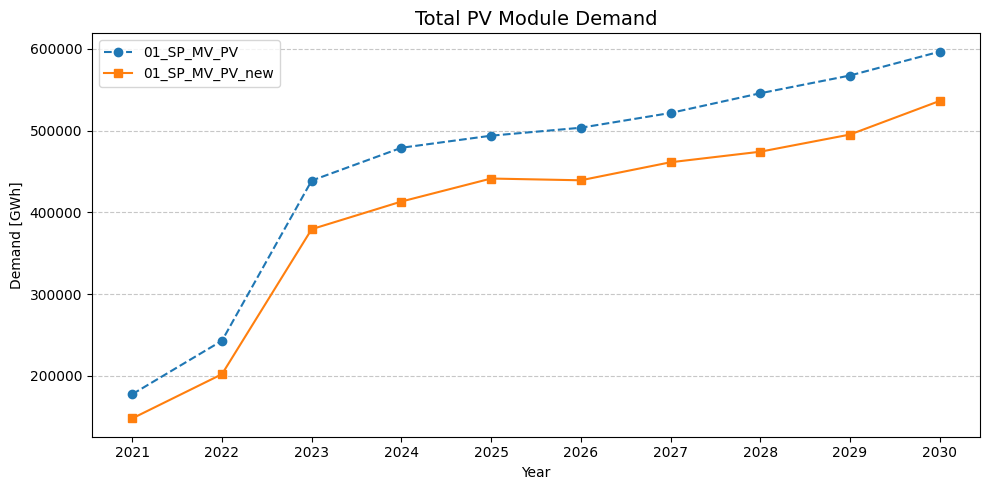

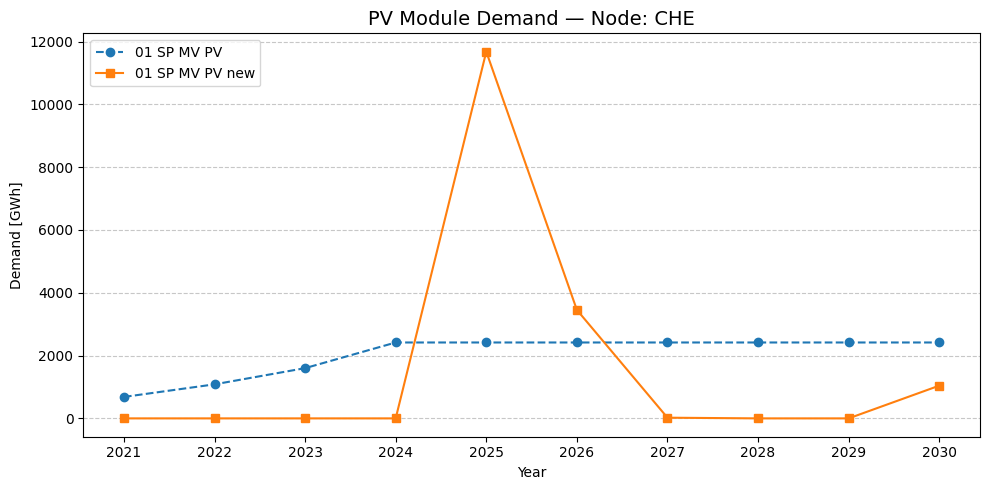

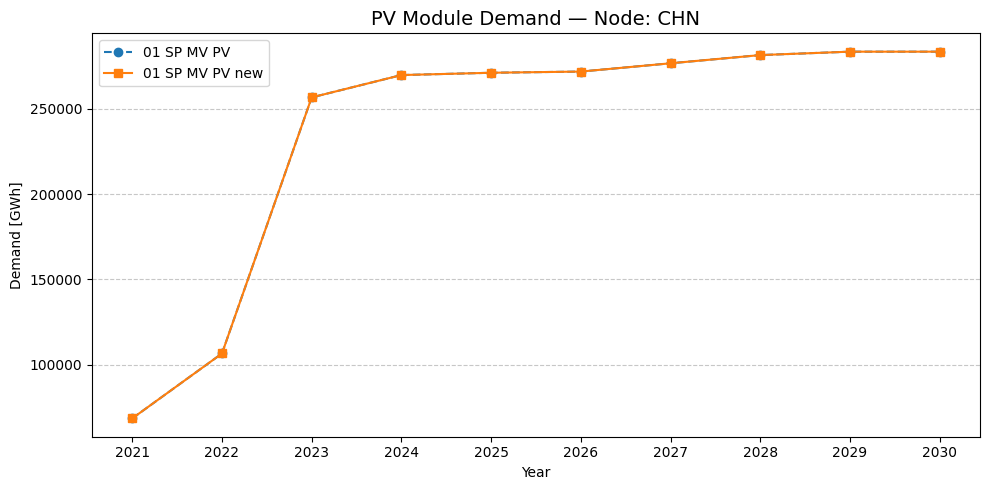

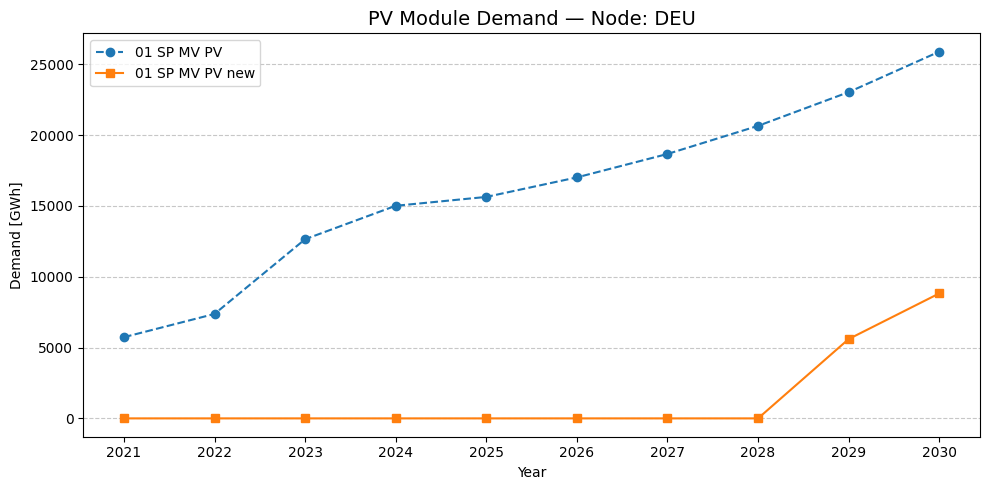

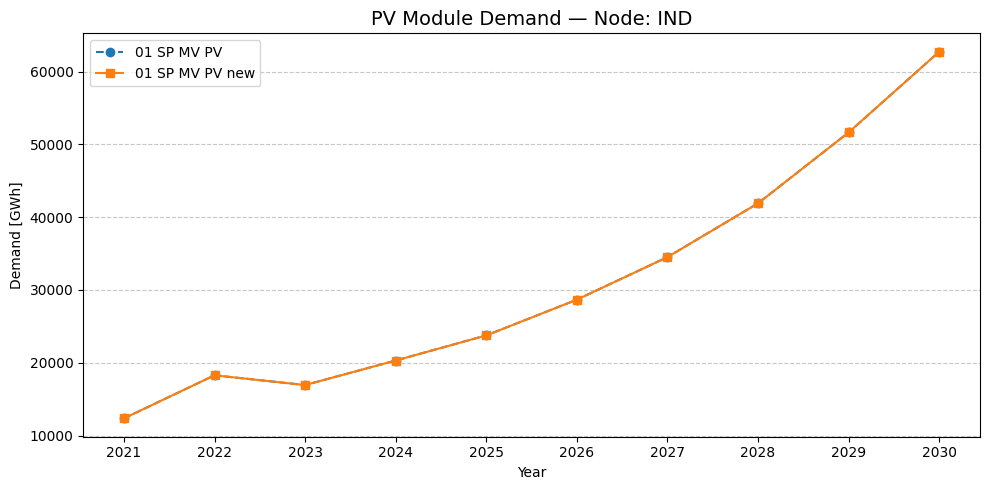

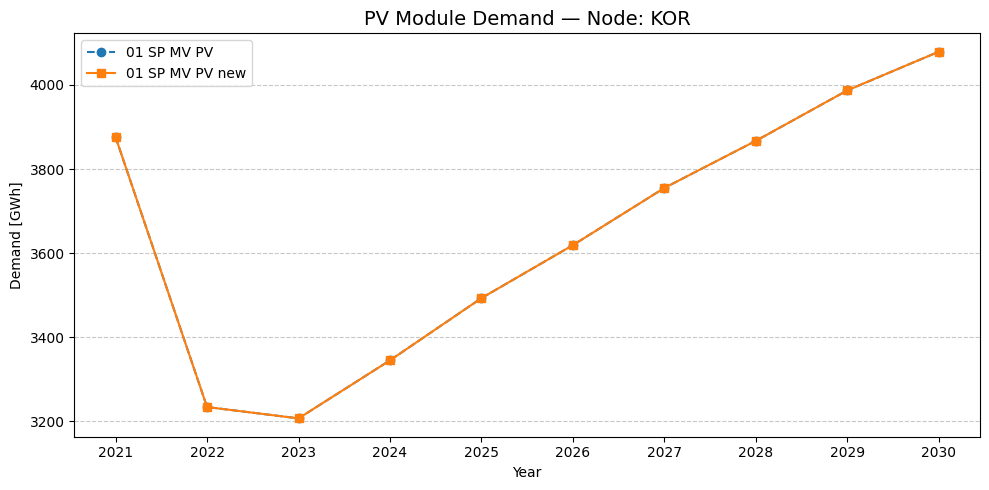

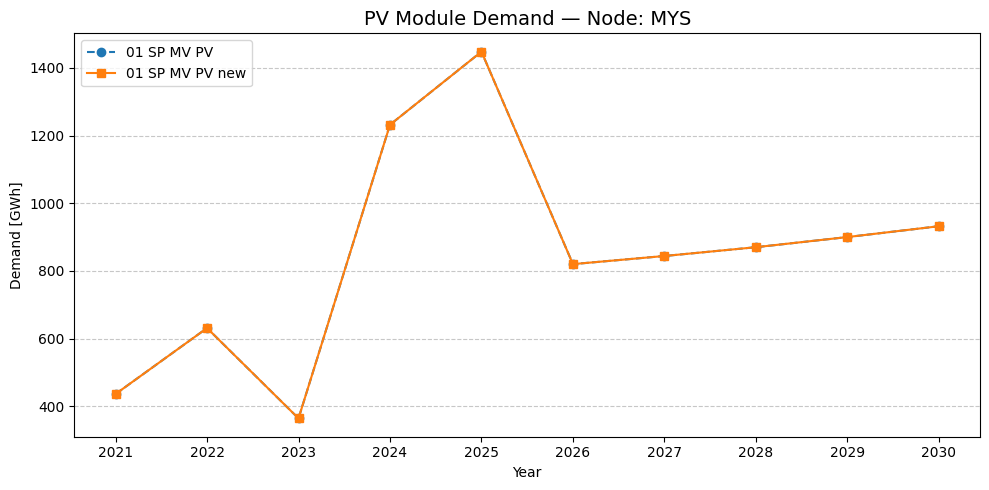

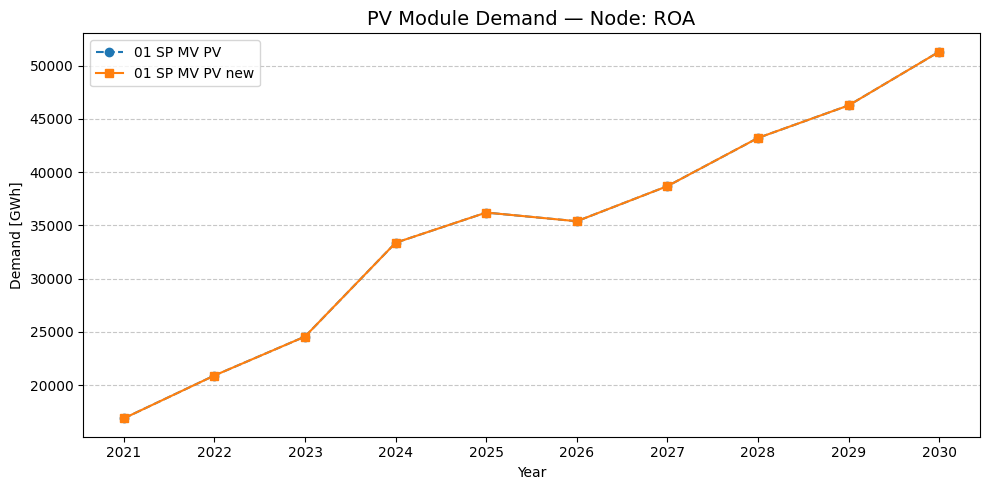

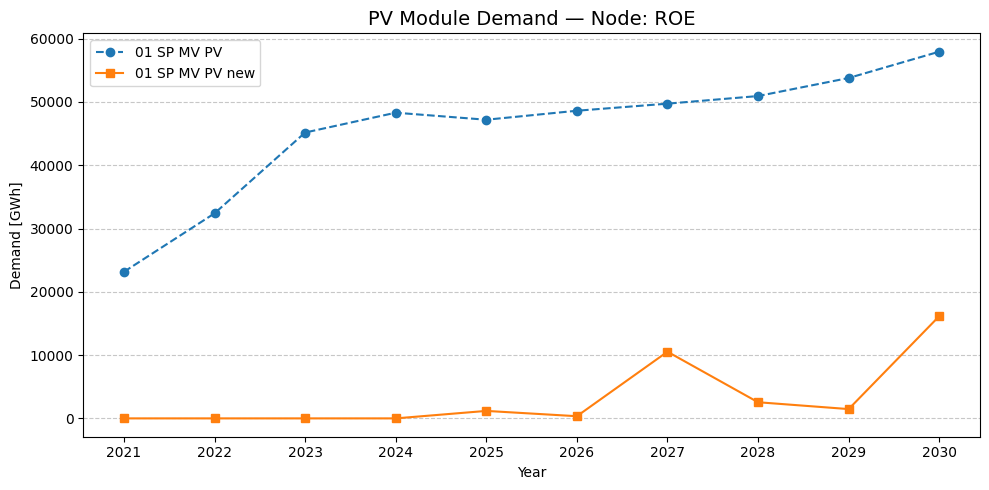

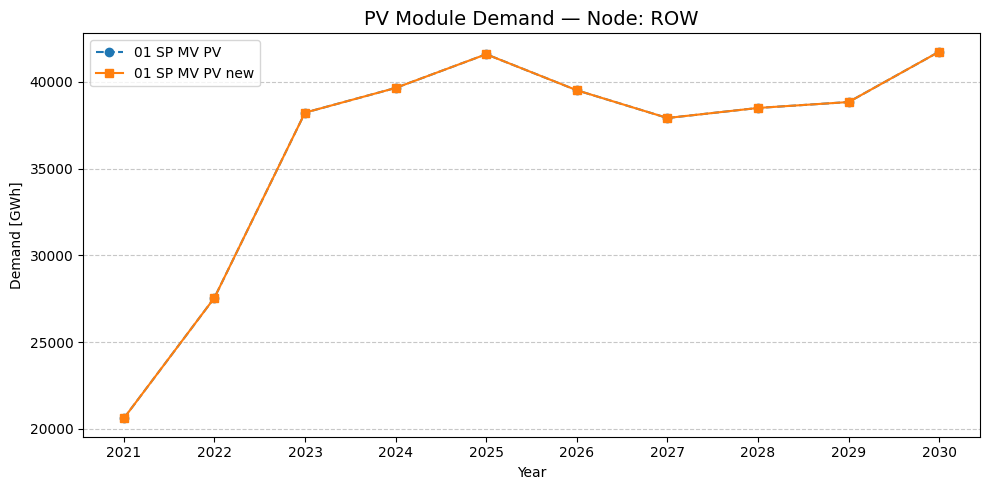

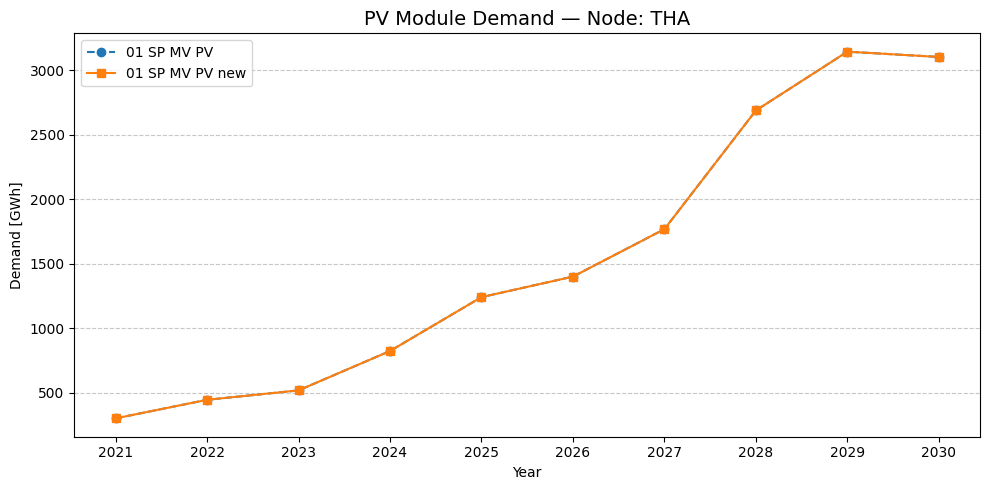

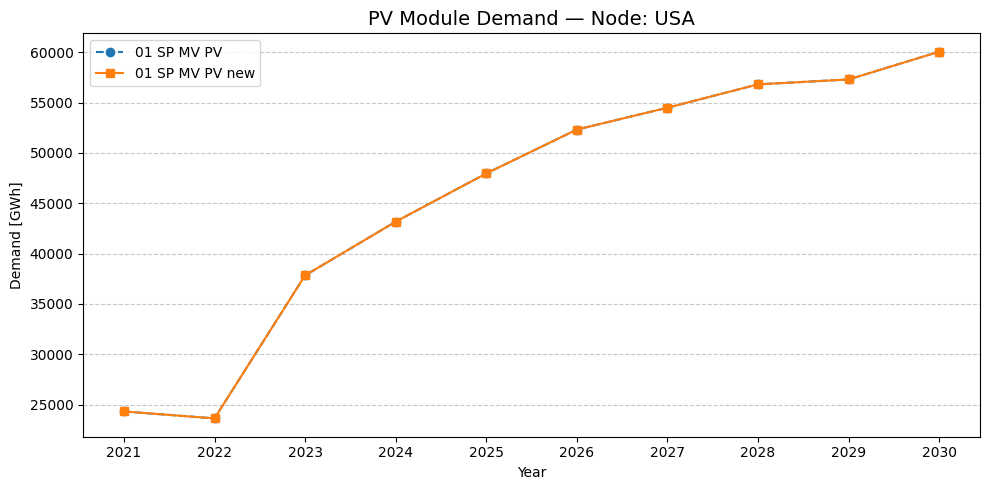

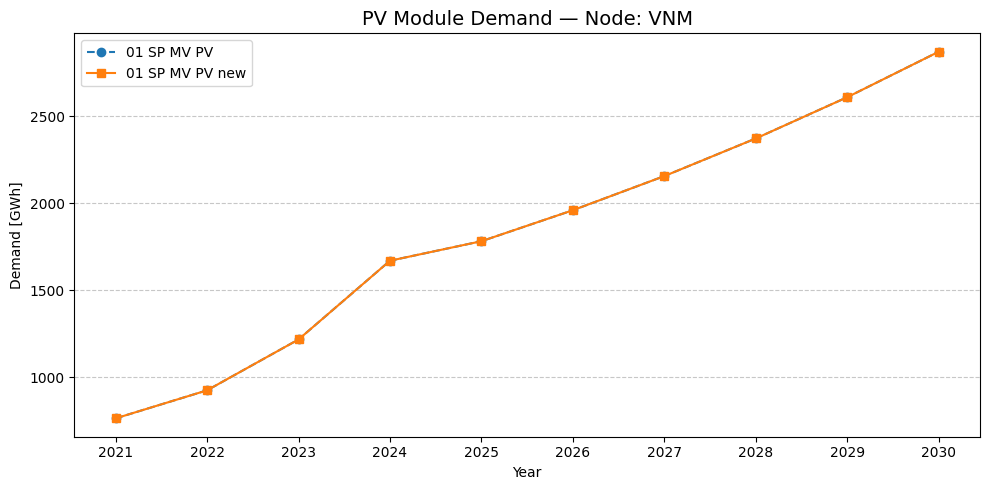


=== PV Module Demand by Node and Year ===


Node: DEU
  0: WT = 5734.00 GWh, WT_new = 0.00 GWh
  1: WT = 7374.00 GWh, WT_new = 0.00 GWh
  2: WT = 12651.00 GWh, WT_new = 0.00 GWh
  3: WT = 15012.00 GWh, WT_new = 0.00 GWh
  4: WT = 15638.00 GWh, WT_new = 0.00 GWh
  5: WT = 17016.00 GWh, WT_new = 0.00 GWh
  6: WT = 18670.00 GWh, WT_new = 0.00 GWh
  7: WT = 20655.00 GWh, WT_new = 0.00 GWh
  8: WT = 23037.00 GWh, WT_new = 5601.10 GWh
  9: WT = 25894.00 GWh, WT_new = 8823.20 GWh

Node: CHE
  0: WT = 683.00 GWh, WT_new = 0.00 GWh
  1: WT = 1084.00 GWh, WT_new = 0.00 GWh
  2: WT = 1600.00 GWh, WT_new = 0.00 GWh
  3: WT = 2417.00 GWh, WT_new = 0.00 GWh
  4: WT = 2417.00 GWh, WT_new = 11677.60 GWh
  5: WT = 2417.00 GWh, WT_new = 3454.50 GWh
  6: WT = 2417.00 GWh, WT_new = 22.00 GWh
  7: WT = 2417.00 GWh, WT_new = 0.00 GWh
  8: WT = 2417.00 GWh, WT_new = 0.00 GWh
  9: WT = 2417.00 GWh, WT_new = 1042.00 GWh

Node: ROE
  0: WT = 23161.00 GWh, WT_new = 0.00 GWh
  1: WT = 32397.00 GWh, WT_new = 0.00

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
dataset_name_1 = '01_SP_MV_PV'
dataset_name_2 = '01_SP_MV_PV_new'
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# === Save Path Settings ===
save_plots = True
save_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\SCM_plots\pv_comparison")
csv_export_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\device_demand_data")

if save_plots:
    os.makedirs(save_path, exist_ok=True)
    os.makedirs(csv_export_path, exist_ok=True)

# === Style Settings ===
start_year = 2021
marker_styles = {dataset_name_1: 'o', dataset_name_2: 's'}
colors = {dataset_name_1: '#1f77b4', dataset_name_2: '#ff7f0e'}
linestyles = {dataset_name_1: '--', dataset_name_2: '-'}
line_widths = {dataset_name_1: 1.5, dataset_name_2: 1.5}

# === Load and Filter Demand ===
demand1 = r1.get_full_ts("demand").reset_index()
demand2 = r2.get_full_ts("demand").reset_index()

demand_pv_1 = demand1[demand1["carrier"].str.lower() == "pv_module"]
demand_pv_2 = demand2[demand2["carrier"].str.lower() == "pv_module"]

time_cols = [col for col in demand_pv_1.columns if isinstance(col, (int, float))]

# === Total Demand Plot ===
def plot_total_pv_demand():
    total1 = demand_pv_1[time_cols].sum()
    total2 = demand_pv_2[time_cols].sum()

    plt.figure(figsize=(10, 5))
    plt.plot(time_cols, total1, label=dataset_name_1, color=colors[dataset_name_1],
             linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1])
    plt.plot(time_cols, total2, label=dataset_name_2, color=colors[dataset_name_2],
             linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2])

    plt.title("Total PV Module Demand", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Demand [GWh]")
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])

    if save_plots:
        plt.savefig(save_path / "pv_module_demand_total.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# === Per-Node Demand Plot ===
def plot_pv_demand_by_node():
    df1_grouped = demand_pv_1.groupby("node")[time_cols].sum()
    df2_grouped = demand_pv_2.groupby("node")[time_cols].sum()
    nodes = sorted(set(df1_grouped.index).union(df2_grouped.index))

    for node in nodes:
        if df1_grouped.loc[node].sum() == 0 and df2_grouped.loc[node].sum() == 0:
            continue

        plt.figure(figsize=(10, 5))
        for label, grouped in zip([dataset_name_1, dataset_name_2], [df1_grouped, df2_grouped]):
            if node in grouped.index:
                plt.plot(time_cols, grouped.loc[node], label=label.replace("_", " "),
                         color=colors[label], linestyle=linestyles[label],
                         marker=marker_styles[label], linewidth=line_widths[label])

        plt.title(f"PV Module Demand — Node: {node}", fontsize=14)
        plt.xlabel("Year")
        plt.ylabel("Demand [GWh]")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend(loc='upper left')
        plt.tight_layout()
        plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])

        if save_plots:
            filename = f"pv_module_demand_{node}.pdf".replace(" ", "_").lower()
            plt.savefig(save_path / filename, format='pdf', bbox_inches='tight')
        plt.show()

# === Export Demand Data by Node and Year ===
def export_pv_demand_data():
    nodes_of_interest = ["DEU", "CHE", "ROE"]

    demand_by_node_1 = (
        demand_pv_1[demand_pv_1["node"].isin(nodes_of_interest)]
        .groupby("node")[time_cols]
        .sum()
        .reindex(nodes_of_interest)
    )

    demand_by_node_2 = (
        demand_pv_2[demand_pv_2["node"].isin(nodes_of_interest)]
        .groupby("node")[time_cols]
        .sum()
        .reindex(nodes_of_interest)
    )

    total1 = demand_by_node_1.sum()
    total2 = demand_by_node_2.sum()

    combined = pd.concat([
        demand_by_node_1.add_suffix(" (WT)"),
        demand_by_node_2.add_suffix(" (WT_new)")
    ], axis=1)

    combined.loc["TOTAL"] = list(total1) + list(total2)
    combined.to_csv(csv_export_path / "pv_module_demand_by_node_and_total.csv")

    print("\n=== PV Module Demand by Node and Year ===\n")
    for node in nodes_of_interest + ["TOTAL"]:
        print(f"\nNode: {node}")
        for year in time_cols:
            val1 = demand_by_node_1.loc[node, year] if node in demand_by_node_1.index else total1[year]
            val2 = demand_by_node_2.loc[node, year] if node in demand_by_node_2.index else total2[year]
            print(f"  {year}: WT = {val1:.2f} GWh, WT_new = {val2:.2f} GWh")

# === Run All ===
plot_total_pv_demand()
plot_pv_demand_by_node()
export_pv_demand_data()
